# 02 — Анализ и визуализация

**Проект:** Moscow Heritage Map  
**Вход:** `processed/okn-cao-points.geojson` (этап 01)  
**Задача:** EDA, извлечение дат, четыре аналитических графика, экспорт агрегатов для d3.js

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import json
import re
import os

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [3]:
import os
os.chdir('/Users/mariakortiashvili/Desktop/moscow heritage')

## 1. Загрузка данных

In [4]:
gdf = gpd.read_file('processed/okn-cao-points.geojson')
print(f'Загружено: {len(gdf)} зданий')
gdf.head(3)

Загружено: 2440 зданий


,name,name_short,address,category,category_label,district,global_id,lat,lon,geometry
0,"Флигель северный, 1770–1780-е гг., 1907 г., ар...",,"Токмаков переулок, дом 21/2, строение 2",регионального значения,Региональный,Басманный,2949522,55.765776,37.671012,POINT (37.67101 55.76578)
1,Евангелическая больница для оказания помощи бе...,,"переулок Обуха, дом 5, строение 1",регионального значения,Региональный,Таганский,2949525,55.752919,37.654045,POINT (37.65405 55.75292)
2,"Дом Перовских (деревянный), начало XIX в.",,"Новая Басманная улица, дом 27, строение 1",федерального значения,Федеральный,Басманный,2949541,55.769870,37.664111,POINT (37.66411 55.76987)


## 2. Распределение по категориям охраны

Две категории: федерального и регионального значения. Простой donut chart — общая картина.

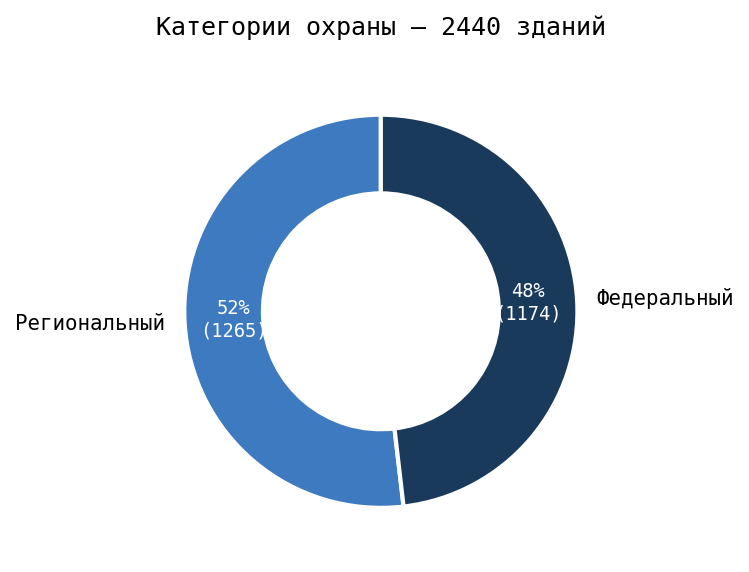

In [5]:
cat_counts = gdf['category_label'].value_counts()
colors = {'Федеральный': '#1A3A5C', 'Региональный': '#3D7ABF'}

fig, ax = plt.subplots(figsize=(5, 5))
wedges, texts, autotexts = ax.pie(
    cat_counts.values, 
    labels=cat_counts.index,
    colors=[colors[c] for c in cat_counts.index],
    autopct=lambda p: f'{p:.0f}%\n({int(p * sum(cat_counts) / 100)})',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 2}
)

for t in autotexts:
    t.set_fontsize(9)
    t.set_color('white')
for t in texts:
    t.set_fontsize(10)

ax.set_title(f'Категории охраны — {len(gdf)} зданий', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('processed/chart-categories.png', bbox_inches='tight')
plt.show()

## 3. Распределение по районам ЦАО

Горизонтальный stacked bar — каждый район разбит на федеральный и региональный. Сортировка по общему количеству.

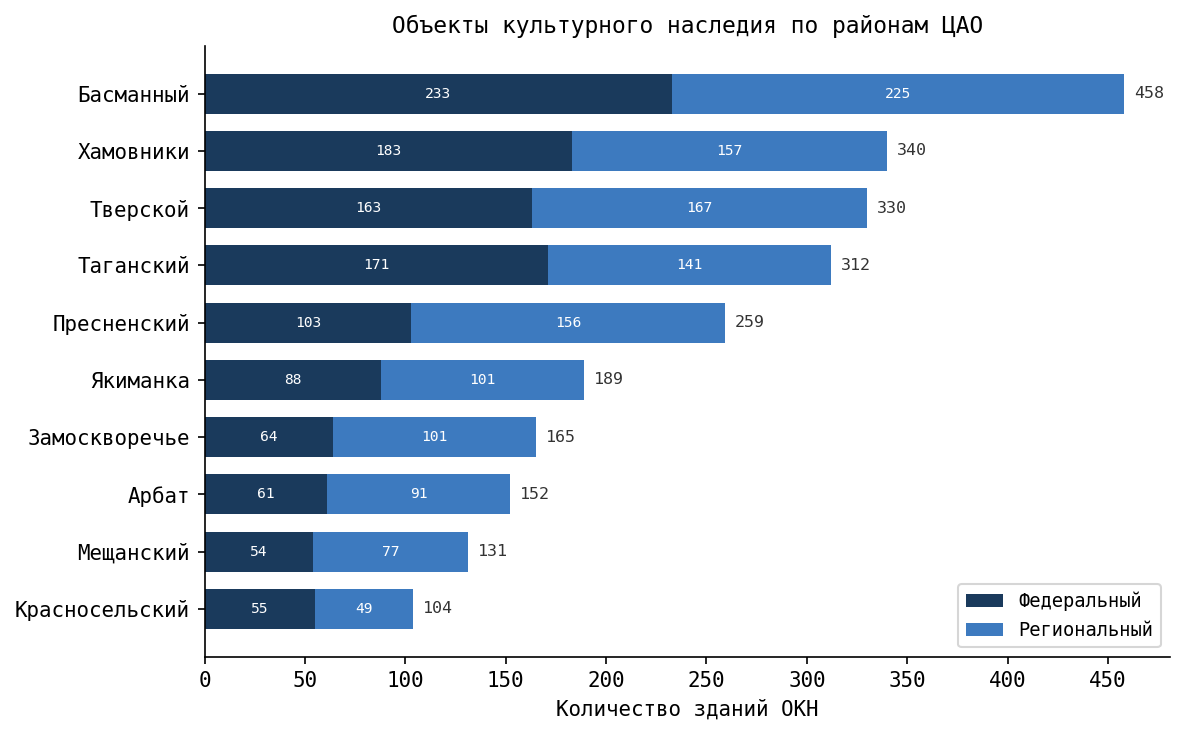

In [6]:
# кросс-таблица: район × категория
cross = pd.crosstab(gdf['district'], gdf['category_label'])
cross = cross.sort_values(cross.columns.tolist(), ascending=True)
# порядок по сумме
cross['total'] = cross.sum(axis=1)
cross = cross.sort_values('total', ascending=True)
cross = cross.drop(columns='total')

fig, ax = plt.subplots(figsize=(8, 5))

left = np.zeros(len(cross))
for cat in ['Федеральный', 'Региональный']:
    vals = cross[cat].values
    bars = ax.barh(cross.index, vals, left=left, 
                   color=colors[cat], label=cat, height=0.7)
    # подписи на барах
    for bar, val in zip(bars, vals):
        if val > 30:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                    str(val), ha='center', va='center', fontsize=7, color='white')
    left += vals

# общие числа справа
for i, (idx, row) in enumerate(cross.iterrows()):
    total = int(row.sum())
    ax.text(total + 5, i, str(total), va='center', fontsize=8, color='#333')

ax.set_xlabel('Количество зданий ОКН')
ax.set_title('Объекты культурного наследия по районам ЦАО', fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
plt.tight_layout()
plt.savefig('processed/chart-districts.png', bbox_inches='tight')
plt.show()

## 4. Извлечение дат из названий объектов

В данных нет отдельного поля «год постройки», но он часто вшит в название:  
`«Дом купца Шурова, 1798 г.»`, `«XVIII в.»`, `«конец XIX – начало XX вв.»`

Стратегия:
- regex для точных годов (1895 г.)
- regex для римских веков (XVIII в., XIX вв.)
- обработка префиксов (начало, конец, середина, 1-я/2-я половина)
- из нескольких дат в одном названии берём **самую раннюю** (дата постройки, остальные — перестройки)

In [8]:
def roman_to_int(s):
    """Римское число → арабское."""
    vals = {'I': 1, 'V': 5, 'X': 10, 'L': 50, 'C': 100}
    result = 0
    for i, c in enumerate(s):
        if i + 1 < len(s) and vals.get(c, 0) < vals.get(s[i + 1], 0):
            result -= vals.get(c, 0)
        else:
            result += vals.get(c, 0)
    return result


def extract_earliest_year(name):
    """Извлекает самую раннюю дату из названия объекта."""
    years = []
    
    # точные годы: 1895, 1770 и т.д.
    for m in re.finditer(r'\b(1[3-9]\d{2}|20[0-2]\d)\b', name):
        years.append(int(m.group(1)))
    
    # римские века: XVIII в., XIX вв., XVIII–XIX, XVIII,
    for m in re.finditer(r'([IVXLC]+)\s*(?=вв?\.|\s*[-–,]|\s*$)', name):
        century = roman_to_int(m.group(1))
        if not (12 <= century <= 21):
            continue
        
        prefix = name[:m.start()]
        
        if re.search(r'(конец|кон\.)\s*$', prefix):
            years.append((century - 1) * 100 + 80)
        elif re.search(r'(начал[оа]|нач\.)\s*$', prefix):
            years.append((century - 1) * 100 + 10)
        elif re.search(r'(середин[аы]|сер\.)\s*$', prefix):
            years.append((century - 1) * 100 + 50)
        elif re.search(r'(перв[аой][яй]?\s+(половин[аы]|пол\.))\s*$', prefix):
            years.append((century - 1) * 100 + 25)
        elif re.search(r'(втор[аой][яй]?\s+(половин[аы]|пол\.))\s*$', prefix):
            years.append((century - 1) * 100 + 75)
        else:
            years.append((century - 1) * 100 + 50)  # середина по умолчанию
    
    return min(years) if years else None

In [9]:
# применяем к данным
gdf['earliest_year'] = gdf['name'].apply(extract_earliest_year)

has_year = gdf['earliest_year'].notna().sum()
print(f'Удалось извлечь дату: {has_year} / {len(gdf)} ({has_year / len(gdf) * 100:.0f}%)')

# проверка на нескольких примерах
samples = [
    'Дом купца Шурова, 1798 г., 1891 г.',
    'Дом, конец XVIII – начало XIX вв.',
    'Колокольня Ивана Великого, 1505-1600 гг.',
    'Жилой дом с росписью в интерьере',
]
print('\nПроверка:')
for s in samples:
    print(f'  {s[:55]:55s} → {extract_earliest_year(s)}')

Удалось извлечь дату: 2122 / 2440 (87%)

Проверка:
  Дом купца Шурова, 1798 г., 1891 г.                      → 1798
  Дом, конец XVIII – начало XIX вв.                       → 1780
  Колокольня Ивана Великого, 1505-1600 гг.                → 1505
  Жилой дом с росписью в интерьере                        → None


## 5. Маппинг на исторические эпохи

In [10]:
def year_to_epoch(y):
    """Год → историческая эпоха."""
    if y is None:
        return None
    if y < 1700:
        return 'до XVIII в.'
    if y < 1800:
        return 'XVIII в.'
    if y < 1850:
        return '1-я пол. XIX в.'
    if y < 1900:
        return '2-я пол. XIX в.'
    if y < 1918:
        return '1900–1917'
    if y < 1946:
        return '1918–1945'
    return 'после 1945'

# порядок эпох для графика
epoch_order = [
    'до XVIII в.', 'XVIII в.', '1-я пол. XIX в.', '2-я пол. XIX в.',
    '1900–1917', '1918–1945', 'после 1945'
]

gdf['epoch'] = gdf['earliest_year'].apply(year_to_epoch)

epoch_counts = gdf['epoch'].value_counts().reindex(epoch_order).fillna(0).astype(int)
print(epoch_counts.to_string())
print(f'\nБез даты: {gdf["epoch"].isna().sum()}')

epoch
до XVIII в.        241
XVIII в.           518
1-я пол. XIX в.    378
2-я пол. XIX в.    520
1900–1917          310
1918–1945          135
после 1945         338

Без даты: 0


## 6. Timeline — распределение по эпохам

Вертикальный bar chart по историческим эпохам. Покрытие ~87% — указываем это на графике.

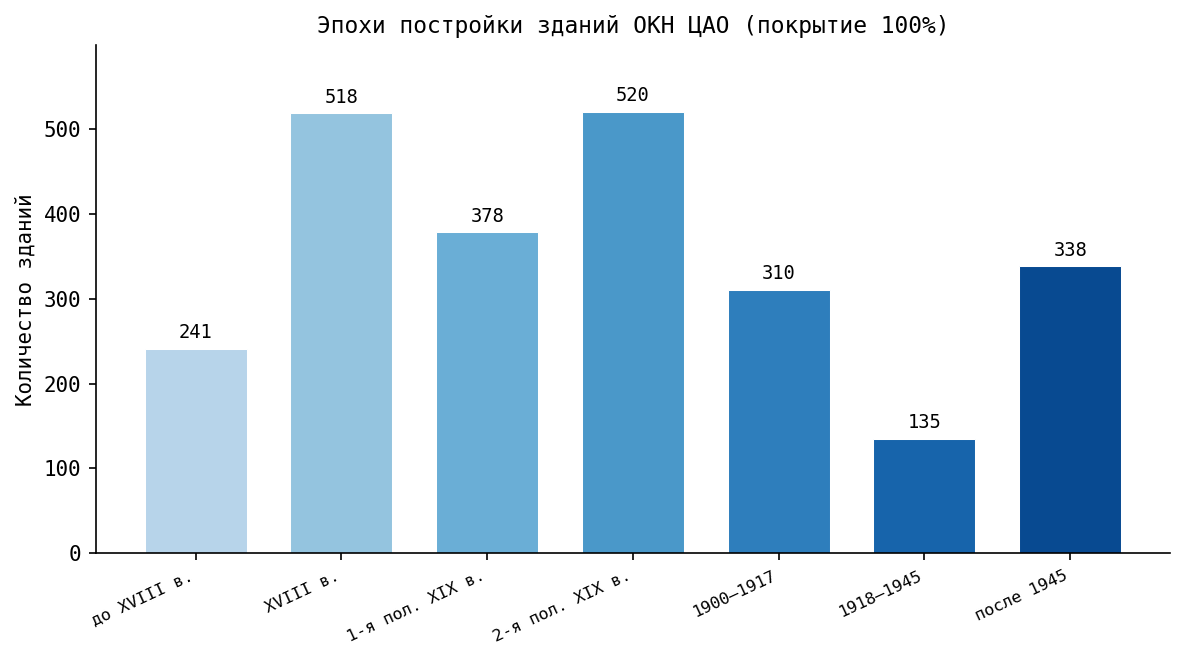

In [11]:
epoch_data = gdf.dropna(subset=['epoch'])

fig, ax = plt.subplots(figsize=(8, 4.5))

# градиент синего от светлого к тёмному
n = len(epoch_order)
cmap_blues = [plt.cm.Blues(0.3 + 0.6 * i / (n - 1)) for i in range(n)]

bars = ax.bar(range(n), epoch_counts.values, color=cmap_blues, width=0.7, 
              edgecolor='white', linewidth=0.5)

# подписи над барами
for bar, val in zip(bars, epoch_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
            str(val), ha='center', va='bottom', fontsize=9)

ax.set_xticks(range(n))
ax.set_xticklabels(epoch_order, fontsize=8, rotation=25, ha='right')
ax.set_ylabel('Количество зданий')

coverage = len(epoch_data) / len(gdf) * 100
ax.set_title(f'Эпохи постройки зданий ОКН ЦАО (покрытие {coverage:.0f}%)', fontsize=11)
ax.set_ylim(0, max(epoch_counts.values) * 1.15)

plt.tight_layout()
plt.savefig('processed/chart-timeline.png', bbox_inches='tight')
plt.show()

## 7. Бонус: район × эпоха (heatmap)

Показывает, какие районы «старше» или «моложе» — интересная находка для раздела Insights на лендинге.

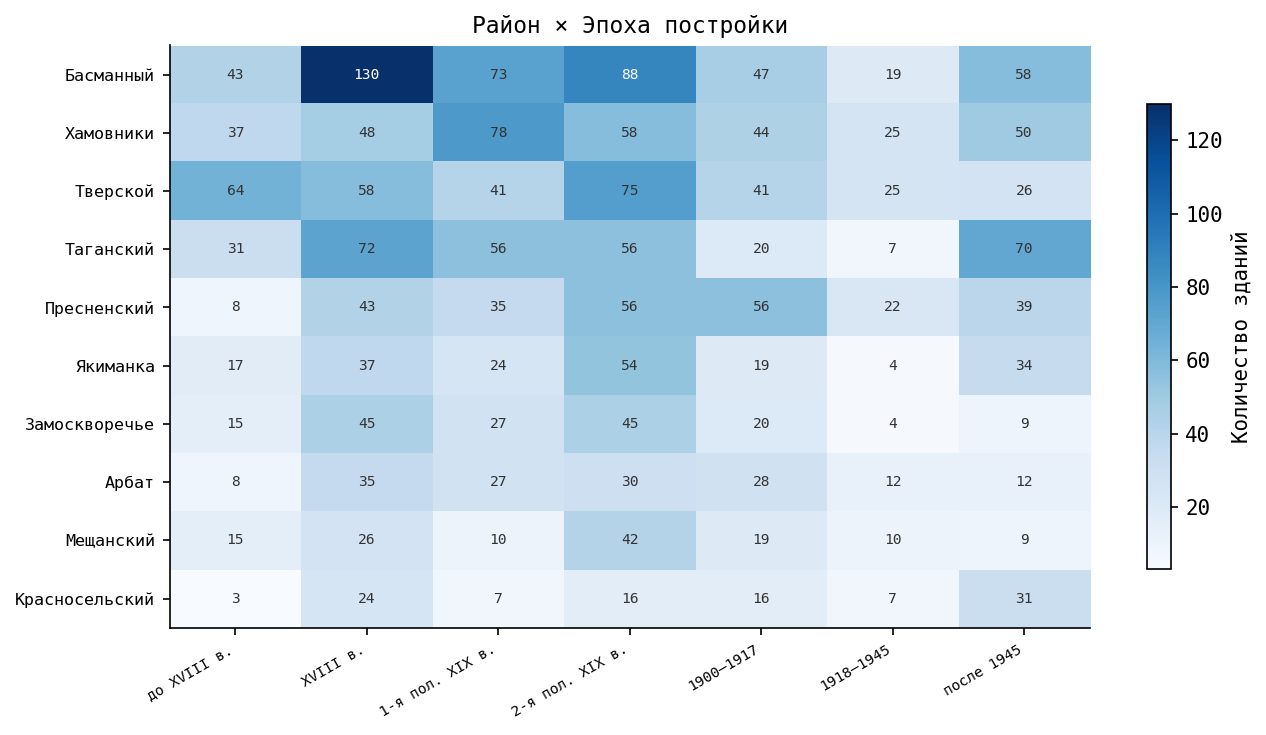

In [12]:
# кросс-таблица район × эпоха
heat = pd.crosstab(gdf['district'], gdf['epoch'])
heat = heat.reindex(columns=epoch_order).fillna(0).astype(int)

# сортируем районы по «среднему возрасту» — районы со старыми зданиями сверху
district_order = cross.index[::-1]  # из графика 3 — по общему количеству
heat = heat.reindex(district_order)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(heat.values, cmap='Blues', aspect='auto')

# подписи в ячейках
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.values[i, j]
        if val > 0:
            color = 'white' if val > heat.values.max() * 0.6 else '#333'
            ax.text(j, i, str(val), ha='center', va='center', fontsize=7, color=color)

ax.set_xticks(range(len(epoch_order)))
ax.set_xticklabels(epoch_order, fontsize=7, rotation=30, ha='right')
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index, fontsize=8)
ax.set_title('Район × Эпоха постройки', fontsize=11)

plt.colorbar(im, ax=ax, shrink=0.8, label='Количество зданий')
plt.tight_layout()
plt.savefig('processed/chart-heatmap-district-epoch.png', bbox_inches='tight')
plt.show()

## 8. Экспорт агрегатов для d3.js

JSON-файлы с готовыми данными для интерактивных графиков на вебе.

In [13]:
# 1) категории
cat_json = cat_counts.reset_index()
cat_json.columns = ['category', 'count']
cat_json['color'] = cat_json['category'].map(colors)
cat_json.to_json('processed/agg-categories.json', orient='records', force_ascii=False)

# 2) районы × категории (для stacked bar)
dist_json = cross.reset_index()
dist_json.columns = ['district', 'Федеральный', 'Региональный']
dist_json['total'] = dist_json['Федеральный'] + dist_json['Региональный']
dist_json = dist_json.sort_values('total', ascending=False)
dist_json.to_json('processed/agg-districts.json', orient='records', force_ascii=False)

# 3) эпохи
epoch_json = epoch_counts.reset_index()
epoch_json.columns = ['epoch', 'count']
epoch_json.to_json('processed/agg-epochs.json', orient='records', force_ascii=False)

# 4) район × эпоха (для heatmap)
heat_json = heat.reset_index().melt(id_vars='district', var_name='epoch', value_name='count')
heat_json.to_json('processed/agg-district-epoch.json', orient='records', force_ascii=False)

print('Экспортировано:')
for f in ['agg-categories.json', 'agg-districts.json', 'agg-epochs.json', 'agg-district-epoch.json']:
    size = os.path.getsize(f'processed/{f}') / 1024
    print(f'  {f}: {size:.1f} КБ')

Экспортировано:
  agg-categories.json: 0.1 КБ
  agg-districts.json: 1.0 КБ
  agg-epochs.json: 0.3 КБ
  agg-district-epoch.json: 4.9 КБ


## 9. Обновление GeoJSON — добавляем эпоху

Добавляем поля `earliest_year` и `epoch` в GeoJSON, чтобы на карте можно было фильтровать по эпохе.

In [14]:
# дописываем новые колонки и пересохраняем
export_cols = ['name', 'name_short', 'address', 'category', 'category_label',
               'district', 'global_id', 'lat', 'lon', 'earliest_year', 'epoch']

gdf_out = gdf[export_cols + ['geometry']].copy()
gdf_out.to_file('processed/okn-cao-points.geojson', driver='GeoJSON')

# для полигонов — нужно подмержить
gdf_poly = gpd.read_file('processed/okn-cao-polygons.geojson')
gdf_poly = gdf_poly.merge(
    gdf[['global_id', 'earliest_year', 'epoch']], 
    on='global_id', how='left'
)
gdf_poly.to_file('processed/okn-cao-polygons.geojson', driver='GeoJSON')

print(f'GeoJSON обновлены: +earliest_year, +epoch')
print(f'Полигоны: {len(gdf_poly)}, Точки: {len(gdf_out)}')

GeoJSON обновлены: +earliest_year, +epoch
Полигоны: 2442, Точки: 2440


## 10. Итоги анализа

In [15]:
coverage = gdf['earliest_year'].notna().sum()

print(f'Зданий: {len(gdf)}')
print(f'Категории: {dict(cat_counts)}')
print(f'Районов: {gdf["district"].nunique()}')
print(f'Извлечение дат: {coverage}/{len(gdf)} ({coverage/len(gdf)*100:.0f}%)')
print(f'\nСамый «старый» район (медиана):')
medians = gdf.dropna(subset=['earliest_year']).groupby('district')['earliest_year'].median().sort_values()
for d, y in medians.items():
    print(f'  {d:20s} {int(y)}')
print(f'\n✓ Готово к этапу 3 (Mapbox) и этапу 4 (d3.js)')

Зданий: 2440
Категории: {'Региональный': 1265, 'Федеральный': 1175}
Районов: 10
Извлечение дат: 2122/2440 (87%)

Самый «старый» район (медиана):
  Басманный            1810
  Таганский            1810
  Замоскворечье        1820
  Тверской             1823
  Хамовники            1831
  Якиманка             1848
  Арбат                1850
  Мещанский            1850
  Красносельский       1851
  Пресненский          1882

✓ Готово к этапу 3 (Mapbox) и этапу 4 (d3.js)
